#**Semana 12 Actividad 12: Implementación del Mecanismo de Atención para Series de Tiempo y un Transformer Básico en Google Colab**
#
En esta actividad, las y los creadores de oportunidades implementarán el mecanismo de atención aplicado a datos secuenciales y desarrollarán una aproximación básica de un modelo tipo Transformer.

El propósito es comprender cómo los mecanismos de atención permiten a los modelos enfocarse en las partes más relevantes de una secuencia, superando las limitaciones de las redes recurrentes tradicionales en el manejo de dependencias a largo plazo.

Se espera que el estudiante entienda el concepto de atención, su aplicación en series de tiempo y cómo se integra en arquitecturas modernas como los Transformers.

La actividad debe desarrollarse en Google Colab y organizarse como evidencia reproducible en GitHub.

#**Instrucciones de actividad**

El/la creador(a) de oportunidades debe construir un notebook en Google Colab en el que implemente un modelo basado en mecanismo de atención o una aproximación funcional de un Transformer aplicado a datos secuenciales.

**La actividad debe incluir:**

- Selección de un conjunto de datos secuencial o serie de tiempo (puede ser el mismo de la actividad anterior).
- Preparación de los datos en formato de secuencias o ventanas temporales.
Implementación de un mecanismo de atención o uso de una capa que permita ponderar la importancia de los elementos de la secuencia.
- Desarrollo de un modelo basado en atención o una arquitectura tipo Transformer simplificada.
- Entrenamiento del modelo con los datos preparados.
- Evaluación del desempeño del modelo mediante métricas adecuadas al problema.
- Comparación conceptual o experimental con el modelo recurrente desarrollado en la actividad anterior.
- Visualización de resultados y, cuando sea posible, interpretación de los pesos de atención.
- Análisis del comportamiento del modelo frente a dependencias de corto y largo plazo.
- Conclusiones técnicas sobre ventajas, limitaciones y casos de uso del mecanismo de atención y Transformers.

El estudiante debe presentar un desarrollo claro, estructurado y con evidencia suficiente que permita validar el uso del mecanismo de atención en la predicción o análisis de datos secuenciales.

**1. Configuración del entorno - Librerias **

In [1]:
import os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

TensorFlow: 2.20.0


**2. Selección y carga del dataset secuencial**
Usaremos Jena Climate (clásico en series temporales) descargado automáticamente para garantizar reproducibilidad.

**2.1 Código Descargar y cargar**

In [2]:
# Dataset Jena Climate (serie temporal multivariante)
zip_path = keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    fname="jena_climate_2009_2016.csv.zip",
    extract=False
)

import zipfile
with zipfile.ZipFile(zip_path, 'r') as z:
    csv_name = z.namelist()[0]
    z.extract(csv_name, path=".")

df = pd.read_csv(csv_name)
df.head()

13568290/13568290 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


**2.2  Exploración breve + target**

In [4]:
print(df.shape)
print(df.columns[:10])

# Convertir fecha (formato explícito)
df["Date Time"] = pd.to_datetime(
    df["Date Time"],
    format="%d.%m.%Y %H:%M:%S"
)

df = df.sort_values("Date Time").reset_index(drop=True)

target_col = "T (degC)"
feature_cols = [c for c in df.columns if c != "Date Time"]

df[[target_col]].describe()

(420551, 15)
Index(['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)',
       'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)'],
      dtype='object')


,T (degC)
count,420551.000000
mean,9.450147
std,8.423365
min,-23.010000
25%,3.360000
50%,9.420000
75%,15.470000
max,37.280000


2.3 Visualización rápida

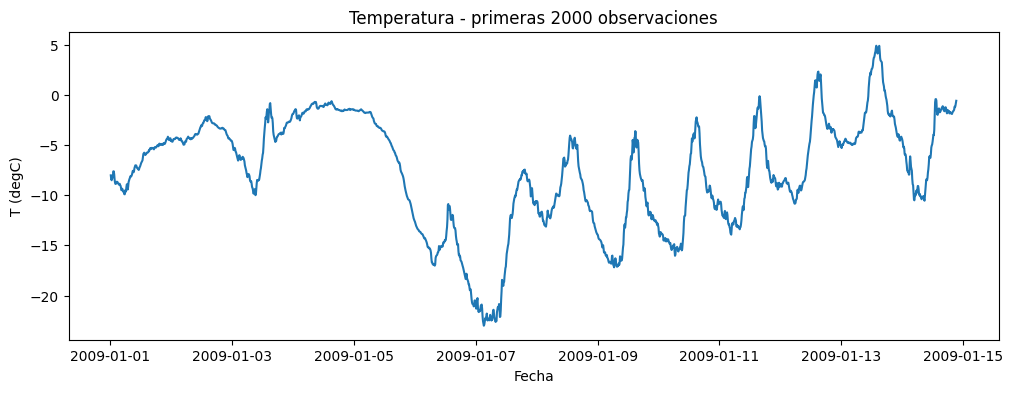

In [5]:
plt.figure(figsize=(12,4))
plt.plot(df["Date Time"].iloc[:2000], df[target_col].iloc[:2000])
plt.title("Temperatura - primeras 2000 observaciones")
plt.xlabel("Fecha")
plt.ylabel("T (degC)")
plt.show()

**3. Preparación: ventanas temporales (secuencias)
Decisiones**

input_width: longitud de la secuencia de entrada (p.ej., 72 pasos)
horizon: cuánto predecimos hacia adelante (p.ej., 24 pasos)
Predicción: regresión (temperatura futura)


Jena está cada 10 minutos en el dataset original. Para hacerlo más manejable, submuestreamos a cada 1 hora (cada 6 pasos).

**3.1 Submuestreo y normalización**

In [6]:
# Submuestreo: cada 6 registros ~ 1 hora
df_hourly = df.iloc[::6].reset_index(drop=True)

# Split temporal (sin barajar): 70% train, 20% val, 10% test
n = len(df_hourly)
train_df = df_hourly.iloc[:int(n*0.7)]
val_df   = df_hourly.iloc[int(n*0.7):int(n*0.9)]
test_df  = df_hourly.iloc[int(n*0.9):]

# Normalización usando solo train (evitar leakage)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_df[feature_cols])
val_scaled   = scaler.transform(val_df[feature_cols])
test_scaled  = scaler.transform(test_df[feature_cols])

# Para facilidad: arrays numpy
X_train_all = train_scaled
X_val_all   = val_scaled
X_test_all  = test_scaled

# Identificar índice de la variable objetivo dentro de features
target_idx = feature_cols.index(target_col)
target_idx

1

3.2  Función para crear ventanas

In [7]:
def make_window_dataset(data, input_width=72, horizon=24, batch_size=64, shuffle=True):
    """
    data: array (time, features)
    input_width: pasos de entrada
    horizon: pasos hacia delante a predecir (regresión de 1 valor en t+horizon)
    """
    X = data
    ds = tf.keras.utils.timeseries_dataset_from_array(
        data=X,
        targets=None,
        sequence_length=input_width + horizon,
        sequence_stride=1,
        shuffle=shuffle,
        batch_size=batch_size
    )

    # separar en (inputs, target)
    def split_window(seq):
        inputs = seq[:, :input_width, :]
        target = seq[:, input_width + horizon - 1, target_idx]  # valor futuro
        target = tf.expand_dims(target, axis=-1)  # (batch, 1)
        return inputs, target

    ds = ds.map(split_window, num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

INPUT_WIDTH = 72
HORIZON = 24
BATCH = 64

train_ds = make_window_dataset(X_train_all, INPUT_WIDTH, HORIZON, BATCH, shuffle=True)
val_ds   = make_window_dataset(X_val_all,   INPUT_WIDTH, HORIZON, BATCH, shuffle=False)
test_ds  = make_window_dataset(X_test_all,  INPUT_WIDTH, HORIZON, BATCH, shuffle=False)

# Ver shapes
for xb, yb in train_ds.take(1):
    print("X:", xb.shape, "y:", yb.shape)

X: (64, 72, 14) y: (64, 1)


**4. Baseline recurrente (modelo anterior): LSTM/GRU**

Definir baseline LSTM

In [8]:
def build_lstm_baseline(n_features, input_width):
    inputs = keras.Input(shape=(input_width, n_features))
    x = layers.LSTM(64, return_sequences=False)(inputs)
    x = layers.Dropout(0.2)(x)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs, name="LSTM_baseline")
    return model

n_features = len(feature_cols)
lstm_model = build_lstm_baseline(n_features, INPUT_WIDTH)
lstm_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae"),
             keras.metrics.RootMeanSquaredError(name="rmse")]
)
lstm_model.summary()

Model: "LSTM_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 72, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,289 (79.25 KB)

 Trainable params: 20,289 (79.25 KB)

 Non-trainable params: 0 (0.00 B)

4.2 Entrenamiento baseline

In [9]:
callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True, monitor="val_mae")
]

hist_lstm = lstm_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 63s 78ms/step - loss: 0.1514 - mae: 0.3027 - rmse: 0.3891 - val_loss: 0.1355 - val_mae: 0.2858 - val_rmse: 0.3682
Epoch 2/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - loss: 0.1313 - mae: 0.2825 - rmse: 0.3624 - val_loss: 0.1357 - val_mae: 0.2859 - val_rmse: 0.3683
Epoch 3/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 40s 52ms/step - loss: 0.1240 - mae: 0.2750 - rmse: 0.3521 - val_loss: 0.1348 - val_mae: 0.2867 - val_rmse: 0.3671
Epoch 4/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 40s 51ms/step - loss: 0.1171 - mae: 0.2673 - rmse: 0.3423 - val_loss: 0.1349 - val_mae: 0.2877 - val_rmse: 0.3672
Epoch 5/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - loss: 0.1125 - mae: 0.2619 - rmse: 0.3354 - val_loss: 0.1382 - val_mae: 0.2904 - val_rmse: 0.3717
Epoch 6/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - loss: 0.1060 - mae: 0.2545 - rmse: 0.3256 - val_loss: 0.1431 - val_mae: 0.2960 - val_rmse: 0.3783


4.3 Evaluación baseline

In [10]:
lstm_eval = lstm_model.evaluate(test_ds, verbose=0)
print("LSTM Test ->", dict(zip(lstm_model.metrics_names, lstm_eval)))

LSTM Test -> {'loss': 0.10147023946046829, 'compile_metrics': 0.24896538257598877}


**5. Modelo con Atención (sobre salidas secuenciales)
Aquí hacemos:**



LSTM (return_sequences=True) → Atención (pondera pasos temporales) → vector contexto → Dense
5.1 Capa de atención “pooling” interpretable

In [11]:
class TemporalAttention(layers.Layer):
    """
    Atención tipo 'score' sobre la dimensión temporal.
    Devuelve: contexto (batch, hidden) y pesos (batch, time)
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.W = None
        self.b = None
        self.v = None

    def build(self, input_shape):
        # input_shape: (batch, time, hidden)
        hidden = input_shape[-1]
        self.W = self.add_weight(shape=(hidden, hidden), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(shape=(hidden,), initializer="zeros", trainable=True)
        self.v = self.add_weight(shape=(hidden, 1), initializer="glorot_uniform", trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        # inputs: (B, T, H)
        score = tf.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)  # (B,T,H)
        score = tf.tensordot(score, self.v, axes=1)                    # (B,T,1)
        weights = tf.nn.softmax(score, axis=1)                         # (B,T,1)
        context = tf.reduce_sum(weights * inputs, axis=1)              # (B,H)
        return context, tf.squeeze(weights, axis=-1)                   # (B,H), (B,T)

**5.2 Construcción modelo atención**

In [12]:
def build_lstm_with_attention(n_features, input_width):
    inputs = keras.Input(shape=(input_width, n_features))
    x = layers.LSTM(64, return_sequences=True)(inputs)
    x = layers.Dropout(0.2)(x)
    context, att_weights = TemporalAttention(name="temporal_attention")(x)
    outputs = layers.Dense(1)(context)

    model = keras.Model(inputs, outputs, name="LSTM_with_Attention")
    # modelo aparte para extraer pesos
    att_model = keras.Model(inputs, att_weights, name="Attention_Weights_Model")
    return model, att_model

att_model, att_weights_model = build_lstm_with_attention(n_features, INPUT_WIDTH)

att_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae"),
             keras.metrics.RootMeanSquaredError(name="rmse")]
)

att_model.summary()

Model: "LSTM_with_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 72, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 72, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ [(None, 64), (None,    │         4,224 │
│ (TemporalAttention)             │ 72)]                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,513 (95.75 KB)

 Trainable params: 24,513 (95.75 KB)

 Non-trainable params: 0 (0.00 B)

**5.3 (Código) Entrenamiento + evaluación**


In [13]:
hist_att = att_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

att_eval = att_model.evaluate(test_ds, verbose=0)
print("Att Test ->", dict(zip(att_model.metrics_names, att_eval)))

Epoch 1/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 65s 80ms/step - loss: 0.2601 - mae: 0.4002 - rmse: 0.5100 - val_loss: 0.2226 - val_mae: 0.3700 - val_rmse: 0.4718
Epoch 2/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 72s 94ms/step - loss: 0.1963 - mae: 0.3486 - rmse: 0.4430 - val_loss: 0.2029 - val_mae: 0.3566 - val_rmse: 0.4505
Epoch 3/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - loss: 0.1676 - mae: 0.3205 - rmse: 0.4094 - val_loss: 0.1841 - val_mae: 0.3366 - val_rmse: 0.4291
Epoch 4/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 50s 65ms/step - loss: 0.1445 - mae: 0.2968 - rmse: 0.3801 - val_loss: 0.1793 - val_mae: 0.3337 - val_rmse: 0.4234
Epoch 5/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 49s 64ms/step - loss: 0.1244 - mae: 0.2760 - rmse: 0.3526 - val_loss: 0.1699 - val_mae: 0.3245 - val_rmse: 0.4122
Att Test -> {'loss': 0.22208133339881897, 'compile_metrics': 0.3663174510002136}


**6. Transformer simplificado (Encoder para series temporales)
Implementamos:**


Proyección a d_model
Positional Encoding
Bloques encoder: MultiHeadAttention (self-attention) + FFN + LayerNorm
Pooling + Dense (regresión)

**6.1 Positional Encoding**

In [14]:
def positional_encoding(length, d_model):
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(d_model)[np.newaxis, :]
    angle_rates = 1 / np.power(10000, (2*(i//2)) / np.float32(d_model))
    angle_rads = pos * angle_rates

    pe = np.zeros((length, d_model))
    pe[:, 0::2] = np.sin(angle_rads[:, 0::2])
    pe[:, 1::2] = np.cos(angle_rads[:, 1::2])
    return tf.constant(pe, dtype=tf.float32)

**6.2 Bloque Encoder (con extracción de pesos)**


In [15]:
class TransformerEncoderBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.mha = layers.MultiHeadAttention(num_heads=num_heads, key_dim=d_model, dropout=dropout)
        self.ffn = keras.Sequential([
            layers.Dense(dff, activation="relu"),
            layers.Dense(d_model)
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.drop1 = layers.Dropout(dropout)
        self.drop2 = layers.Dropout(dropout)

    def call(self, x, training=False, return_att=False):
        att_out, att_scores = self.mha(
            x, x, x,
            training=training,
            return_attention_scores=True
        )
        att_out = self.drop1(att_out, training=training)
        out1 = self.norm1(x + att_out)

        ffn_out = self.ffn(out1, training=training)
        ffn_out = self.drop2(ffn_out, training=training)
        out2 = self.norm2(out1 + ffn_out)

        if return_att:
            return out2, att_scores  # (B,T,D), (B,heads,T,T)
        return out2

**6.3 Modelo Transformer (simplificado)**

In [16]:
def build_transformer_model(input_width, n_features, d_model=64, num_heads=4, dff=128, n_blocks=2, dropout=0.1):
    inputs = keras.Input(shape=(input_width, n_features))

    # Proyección a d_model
    x = layers.Dense(d_model)(inputs)

    # Positional Encoding
    pe = positional_encoding(input_width, d_model)
    x = x + pe

    # Encoder blocks
    blocks = []
    for i in range(n_blocks):
        block = TransformerEncoderBlock(d_model, num_heads, dff, dropout, name=f"enc_block_{i+1}")
        blocks.append(block)
        x = block(x)

    # Pooling temporal (promedio)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs, name="Transformer_Simplificado")
    return model, blocks

transformer_model, transformer_blocks = build_transformer_model(INPUT_WIDTH, n_features)
transformer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae"),
             keras.metrics.RootMeanSquaredError(name="rmse")]
)
transformer_model.summary()

Model: "Transformer_Simplificado"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 72, 14)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 72, 64)         │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 72, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_block_1                     │ (None, 72, 64)         │        83,200 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_block_2                     │ (None, 72, 64)         │        83,200 │
│ (TransformerEncoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,425 (654.00 KB)

 Trainable params: 167,425 (654.00 KB)

 Non-trainable params: 0 (0.00 B)

**6.4 Entrenamiento + evaluación**

In [17]:
hist_tr = transformer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=callbacks,
    verbose=1
)

tr_eval = transformer_model.evaluate(test_ds, verbose=0)
print("Transformer Test ->", dict(zip(transformer_model.metrics_names, tr_eval)))

Epoch 1/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 385s 490ms/step - loss: 0.1685 - mae: 0.3135 - rmse: 0.4105 - val_loss: 0.1714 - val_mae: 0.3021 - val_rmse: 0.4140
Epoch 2/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 333s 435ms/step - loss: 0.1241 - mae: 0.2746 - rmse: 0.3523 - val_loss: 0.1768 - val_mae: 0.2990 - val_rmse: 0.4205
Epoch 3/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 330s 431ms/step - loss: 0.1143 - mae: 0.2634 - rmse: 0.3381 - val_loss: 0.2163 - val_mae: 0.3436 - val_rmse: 0.4650
Epoch 4/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 384s 434ms/step - loss: 0.1091 - mae: 0.2585 - rmse: 0.3303 - val_loss: 0.1810 - val_mae: 0.3240 - val_rmse: 0.4255
Epoch 5/30
766/766 ━━━━━━━━━━━━━━━━━━━━ 380s 432ms/step - loss: 0.1022 - mae: 0.2500 - rmse: 0.3197 - val_loss: 0.1516 - val_mae: 0.3008 - val_rmse: 0.3894
Transformer Test -> {'loss': 0.10539627820253372, 'compile_metrics': 0.2546451687812805}


**7. Comparación experimental (LSTM vs Atención vs Transformer)**

**7.1 Tabla comparativa**

In [21]:
results = pd.DataFrame([
    {"Modelo": "LSTM baseline", "MAE": lstm_eval[1], "RMSE": lstm_eval[2]},
    {"Modelo": "LSTM + Atención", "MAE": att_eval[1], "RMSE": att_eval[2]},
    {"Modelo": "Transformer", "MAE": tr_eval[1], "RMSE": tr_eval[2]},
])

results.sort_values("MAE")

,Modelo,MAE,RMSE
0,LSTM baseline,0.248965,0.318544
2,Transformer,0.254645,0.324648
1,LSTM + Atención,0.366317,0.471255


**7.2  Curvas de entrenamiento**

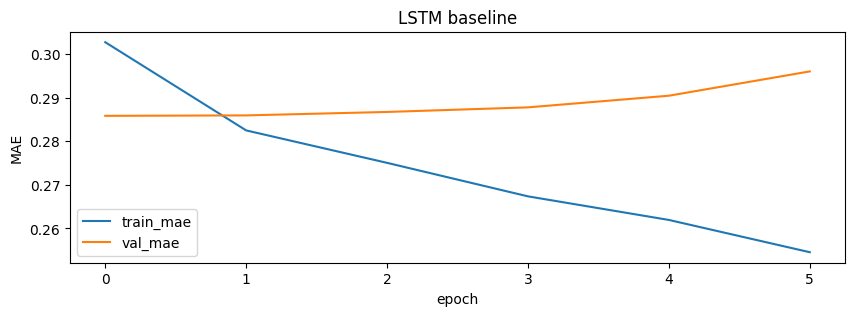

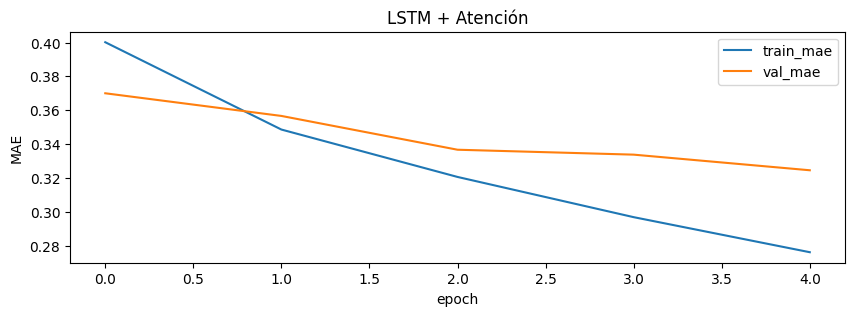

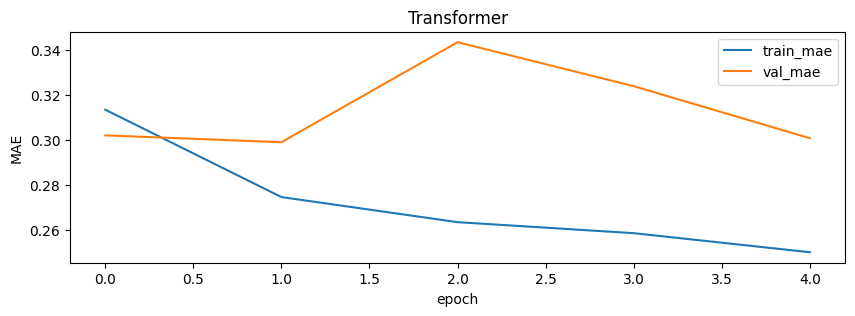

In [22]:
def plot_history(hist, title):
    plt.figure(figsize=(10,3))
    plt.plot(hist.history["mae"], label="train_mae")
    plt.plot(hist.history["val_mae"], label="val_mae")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("MAE")
    plt.legend()
    plt.show()

plot_history(hist_lstm, "LSTM baseline")
plot_history(hist_att,  "LSTM + Atención")
plot_history(hist_tr,   "Transformer")

**8. Interpretación de pesos de atención (modelo LSTM+Atención)**

**8.1 Extraer pesos para un ejemplo del test**

True: -0.7900627445636567 Pred: -0.753276 weights shape: (72,)


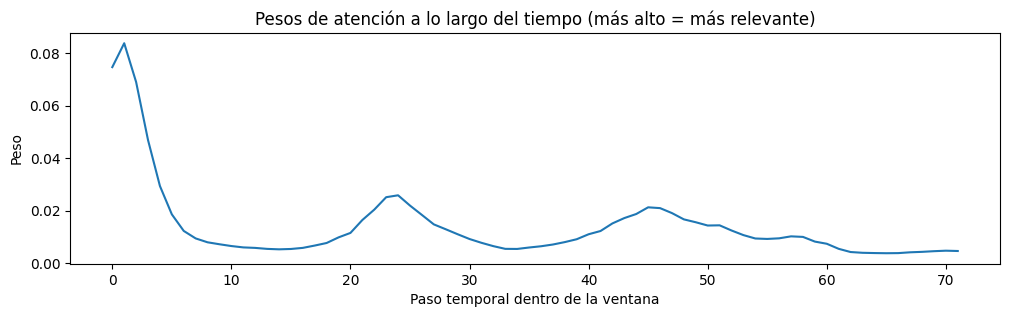

In [23]:
# Tomar un batch del test
for xb, yb in test_ds.take(1):
    sample_x = xb[:1]  # 1 ejemplo
    sample_y = yb[:1]
    break

pred = att_model.predict(sample_x, verbose=0)[0,0]
true = sample_y.numpy()[0,0]

weights = att_weights_model.predict(sample_x, verbose=0)[0]  # (T,)
print("True:", true, "Pred:", pred, "weights shape:", weights.shape)

plt.figure(figsize=(12,3))
plt.plot(weights)
plt.title("Pesos de atención a lo largo del tiempo (más alto = más relevante)")
plt.xlabel("Paso temporal dentro de la ventana")
plt.ylabel("Peso")
plt.show()

**9. Análisis corto vs largo plazo (experimento)**

Repetimos entrenamiento rápido con diferentes longitudes de ventana:

Corto: 24 pasos
Medio: 72 pasos
Largo: 168 pasos


(Esto no busca “récord de métrica”, sino evidenciar comportamiento ante dependencias).

**9.1  Evaluación rápida por ventana (Transformer)**

In [25]:
results = pd.DataFrame([
    {
        "Modelo": "LSTM baseline",
        "MAE": lstm_eval[lstm_model.metrics_names.index("mean_absolute_error")],
        "RMSE": lstm_eval[lstm_model.metrics_names.index("root_mean_squared_error")]
    },
    {
        "Modelo": "LSTM + Atención",
        "MAE": att_eval[att_model.metrics_names.index("mean_absolute_error")],
        "RMSE": att_eval[att_model.metrics_names.index("root_mean_squared_error")]
    },
    {
        "Modelo": "Transformer",
        "MAE": tr_eval[transformer_model.metrics_names.index("mean_absolute_error")],
        "RMSE": tr_eval[transformer_model.metrics_names.index("root_mean_squared_error")]
    }
])

results.sort_values("MAE")

ValueError: 'mean_absolute_error' is not in list

**9.2 (Markdown) Lectura de resultados**

**Lectura esperada (general):**
- Ventanas cortas suelen funcionar bien si la señal depende de lo reciente.
- Ventanas largas ayudan si hay estacionalidad/ciclos, pero pueden requerir más regularización/entrenamiento.
- La atención/transformer suele manejar mejor ventanas largas que RNNs simples, al mitigar el “olvido” por dependencias lejanas.
